# Predicting Next-Minute ETF Direction with Random Forests

## A compact comparison of model complexity and cross-symbol context

This notebook combines three related experiments into one reproducible workflow:

1. **SPY baseline:** one primary SPY feature plus requested QQQ context
2. **SPY expanded model:** five primary SPY features plus QQQ context
3. **SLV cross-asset model:** five primary SLV features plus GLD context

The research question is intentionally narrow: **does a small set of market
microstructure features improve next-minute UP/DOWN classification over a
simple baseline?**

All models use one-minute DataBento CSV files, regular trading hours, the same
Random Forest settings, and chronological train/validation/test splits. The two
SPY models use the exact same rows and split dates so that their comparison is
not affected by different samples.

> The terms “one-feature” and “five-feature” refer to the number of features
> from the predicted symbol. With cross-symbol context enabled, the models use
> one additional QQQ or GLD feature.

## 1. Imports and experiment configuration

The main settings are kept together below. Feature lists and cross-symbol
inputs can be changed without editing the remainder of the notebook.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

# ---------------------------------------------------------------------
# Data and target settings
# ---------------------------------------------------------------------
DATA_FOLDER = Path("SYMBOLS_DATA")
MARKET_TIMEZONE = "America/New_York"
START_DATE = None                  # Example: "2024-01-01"
END_DATE = None                    # Example: "2026-01-01"

# At 0.0, every consecutive next-minute move is labeled UP or DOWN.
# A positive value removes moves inside a neutral band of +/- this many bps.
TARGET_THRESHOLD_BPS = 0.0
CONFIDENCE_THRESHOLD = 0.60

# Preserve time order: oldest 64% / next 16% / newest 20%.
TRAIN_FRACTION = 0.64
VALIDATION_FRACTION = 0.16
TEST_FRACTION = 0.20

# Curves show train and validation accuracy as trees are added.
TREE_COUNTS = [10, 25, 50, 75, 100]
RANDOM_SEED = 42

RANDOM_FOREST_SETTINGS = {
    "max_depth": 5,
    "min_samples_leaf": 100,
    "max_features": "sqrt",
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
}

# ---------------------------------------------------------------------
# Select features here
# ---------------------------------------------------------------------
ONE_PRIMARY_FEATURE = [
    "last_sale_vs_mid_bps",
]

FIVE_PRIMARY_FEATURES = [
    "last_sale_vs_mid_bps",
    "return_1m",
    "volatility_20m",
    "momentum_5m",
    "relative_spread_bps",
]

# Set cross_symbol to None to disable the optional cross-symbol feature.
EXPERIMENTS = [
    {
        "name": "SPY baseline: 1 primary + QQQ context",
        "symbol": "SPY",
        "primary_features": ONE_PRIMARY_FEATURE,
        "cross_symbol": "QQQ",
    },
    {
        "name": "SPY expanded: 5 primary + QQQ context",
        "symbol": "SPY",
        "primary_features": FIVE_PRIMARY_FEATURES,
        "cross_symbol": "QQQ",
    },
    {
        "name": "SLV cross-asset: 5 primary + GLD context",
        "symbol": "SLV",
        "primary_features": FIVE_PRIMARY_FEATURES,
        "cross_symbol": "GLD",
    },
]

if not np.isclose(
    TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION,
    1.0,
):
    raise ValueError("Train, validation, and test fractions must sum to 1.")

if TREE_COUNTS != sorted(set(TREE_COUNTS)) or TREE_COUNTS[0] <= 0:
    raise ValueError("TREE_COUNTS must contain unique increasing positive values.")

print("Configured experiments:")
for experiment in EXPERIMENTS:
    context = experiment["cross_symbol"] or "OFF"
    print(
        f"- {experiment['name']} | "
        f"primary features={len(experiment['primary_features'])} | "
        f"cross-symbol={context}"
    )

c:\Users\neilk\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\neilk\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Configured experiments:
- SPY baseline: 1 primary + QQQ context | primary features=1 | cross-symbol=QQQ
- SPY expanded: 5 primary + QQQ context | primary features=5 | cross-symbol=QQQ
- SLV cross-asset: 5 primary + GLD context | primary features=5 | cross-symbol=GLD


## 2. Load and clean the DataBento CSV files

Files are discovered by symbol, regardless of filename capitalization. Timestamps
are converted to U.S. Eastern time and filtered to regular trading hours
(9:30 a.m.–4:00 p.m.). Cross-symbol observations are joined only when both
symbols have the exact same completed one-minute timestamp.

In [2]:
REQUIRED_COLUMNS = [
    "timestamp",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "bid",
    "ask",
    "bid_size",
    "ask_size",
    "last_sale",
]

NUMERIC_COLUMNS = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "bid",
    "ask",
    "bid_size",
    "ask_size",
    "last_sale",
]


def discover_symbol_files(data_folder):
    if not data_folder.exists():
        raise FileNotFoundError(
            f"Data folder not found: {data_folder.resolve()}"
        )

    symbol_files = {}
    for file_path in data_folder.glob("*.csv"):
        symbol = file_path.stem.strip().upper()
        if symbol in symbol_files:
            raise ValueError(f"Duplicate CSV files found for {symbol}.")
        symbol_files[symbol] = file_path

    if not symbol_files:
        raise FileNotFoundError(
            f"No CSV files found in {data_folder.resolve()}"
        )

    return symbol_files


SYMBOL_FILES = discover_symbol_files(DATA_FOLDER)


def load_symbol(symbol):
    symbol = symbol.strip().upper()

    if symbol not in SYMBOL_FILES:
        raise FileNotFoundError(
            f"No CSV found for {symbol}. "
            f"Available symbols: {sorted(SYMBOL_FILES)}"
        )

    file_path = SYMBOL_FILES[symbol]
    header = pd.read_csv(file_path, nrows=0).columns.tolist()
    missing = sorted(set(REQUIRED_COLUMNS) - set(header))

    if missing:
        raise ValueError(f"{file_path.name} is missing columns: {missing}")

    data = pd.read_csv(file_path, usecols=REQUIRED_COLUMNS)
    data["timestamp"] = pd.to_datetime(
        data["timestamp"],
        utc=True,
        errors="coerce",
    )

    for column in NUMERIC_COLUMNS:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    data = data.dropna(subset=["timestamp", "close"]).copy()

    if START_DATE is not None:
        data = data[
            data["timestamp"] >= pd.Timestamp(START_DATE, tz="UTC")
        ].copy()

    if END_DATE is not None:
        data = data[
            data["timestamp"] < pd.Timestamp(END_DATE, tz="UTC")
        ].copy()

    data["timestamp_et"] = data["timestamp"].dt.tz_convert(
        MARKET_TIMEZONE
    )
    data["trade_date"] = data["timestamp_et"].dt.date
    data["minute_of_day"] = (
        data["timestamp_et"].dt.hour * 60
        + data["timestamp_et"].dt.minute
    )

    data = data[
        (data["timestamp_et"].dt.dayofweek < 5)
        & (data["minute_of_day"] >= 9 * 60 + 30)
        & (data["minute_of_day"] < 16 * 60)
    ].copy()

    return (
        data
        .drop_duplicates(subset="timestamp", keep="last")
        .sort_values("timestamp")
        .reset_index(drop=True)
    )


def calculate_last_sale_vs_mid(data):
    midpoint = (data["bid"] + data["ask"]) / 2
    valid_quote = (
        midpoint.gt(0)
        & data["bid"].notna()
        & data["ask"].notna()
        & data["last_sale"].notna()
        & data["bid"].gt(0)
        & data["ask"].ge(data["bid"])
    )

    return np.where(
        valid_quote,
        (data["last_sale"] - midpoint) / midpoint * 10_000,
        np.nan,
    )


print("Available CSV symbols:")
print(", ".join(sorted(SYMBOL_FILES)))

Available CSV symbols:
GLD, HYG, IWM, QQQ, SLV, SPY, TLT, VXX


## 3. Engineer features and the next-minute target

The primary feature, `last_sale_vs_mid_bps`, measures where the latest trade
occurred relative to the bid–ask midpoint. Positive values indicate trading
above the midpoint; negative values indicate trading below it.

All rolling price features reset each trading day. The target uses only the
next consecutive minute, so it never crosses an overnight or missing-data gap.

In [3]:
AVAILABLE_PRIMARY_FEATURES = {
    "last_sale_vs_mid_bps",
    "return_1m",
    "volatility_20m",
    "momentum_5m",
    "relative_spread_bps",
}


def build_model_data(symbol, cross_symbol, required_features):
    symbol = symbol.strip().upper()
    cross_symbol = (
        cross_symbol.strip().upper()
        if cross_symbol is not None
        else None
    )

    data = load_symbol(symbol)

    if cross_symbol is not None:
        if cross_symbol == symbol:
            raise ValueError("Cross-symbol input must use a different symbol.")

        context = load_symbol(cross_symbol)
        cross_feature = (
            f"{cross_symbol.lower()}_last_sale_vs_mid_bps"
        )
        context[cross_feature] = calculate_last_sale_vs_mid(context)

        data = data.merge(
            context[["timestamp", cross_feature]],
            on="timestamp",
            how="inner",
            validate="one_to_one",
        )

    midpoint = (data["bid"] + data["ask"]) / 2
    data["last_sale_vs_mid_bps"] = calculate_last_sale_vs_mid(data)
    data["relative_spread_bps"] = np.where(
        midpoint.gt(0),
        (data["ask"] - data["bid"]) / midpoint * 10_000,
        np.nan,
    )

    session_groups = data.groupby("trade_date", group_keys=False)

    previous_timestamp = session_groups["timestamp"].shift(1)
    data["return_1m"] = session_groups["close"].pct_change(1)
    consecutive_previous_minute = (
        data["timestamp"] - previous_timestamp
        == pd.Timedelta(minutes=1)
    )
    data.loc[~consecutive_previous_minute, "return_1m"] = np.nan

    five_rows_back = session_groups["timestamp"].shift(5)
    data["momentum_5m"] = session_groups["close"].pct_change(5)
    consecutive_five_minute_window = (
        data["timestamp"] - five_rows_back
        == pd.Timedelta(minutes=5)
    )
    data.loc[
        ~consecutive_five_minute_window,
        "momentum_5m",
    ] = np.nan

    data["volatility_20m"] = (
        data.groupby("trade_date")["return_1m"]
        .transform(
            lambda values: values
            .rolling(20, min_periods=10)
            .std(ddof=0)
        )
    )

    next_timestamp = session_groups["timestamp"].shift(-1)
    data["next_close"] = session_groups["close"].shift(-1)
    data["target_return"] = data["next_close"] / data["close"] - 1

    consecutive_next_minute = (
        next_timestamp - data["timestamp"]
        == pd.Timedelta(minutes=1)
    )

    threshold = TARGET_THRESHOLD_BPS / 10_000

    if threshold == 0:
        data["target"] = np.where(
            consecutive_next_minute,
            (data["target_return"] > 0).astype(float),
            np.nan,
        )
    else:
        data["target"] = np.where(
            consecutive_next_minute
            & (data["target_return"] > threshold),
            1.0,
            np.where(
                consecutive_next_minute
                & (data["target_return"] < -threshold),
                0.0,
                np.nan,
            ),
        )

    data = data.replace([np.inf, -np.inf], np.nan)
    model_data = (
        data
        .dropna(
            subset=[
                *required_features,
                "target",
                "target_return",
                "next_close",
            ]
        )
        .copy()
        .reset_index(drop=True)
    )
    model_data["target"] = model_data["target"].astype(int)

    if model_data.empty:
        raise ValueError(
            f"No usable rows remain for {symbol} and {cross_symbol}."
        )

    return model_data

## 4. Create shared datasets and chronological splits

Each symbol/cross-symbol pair is prepared once using the union of features
required by its experiments. This guarantees that both SPY models use the
same observations, target labels, and split boundaries.

In [4]:
def cross_feature_name(cross_symbol):
    if cross_symbol is None:
        return None
    return f"{cross_symbol.lower()}_last_sale_vs_mid_bps"


DATASET_REQUIREMENTS = {}

for experiment in EXPERIMENTS:
    symbol = experiment["symbol"].strip().upper()
    cross_symbol = experiment["cross_symbol"]
    cross_symbol = (
        cross_symbol.strip().upper()
        if cross_symbol is not None
        else None
    )

    unknown = (
        set(experiment["primary_features"])
        - AVAILABLE_PRIMARY_FEATURES
    )
    if unknown:
        raise ValueError(
            f"Unknown features in {experiment['name']}: {sorted(unknown)}"
        )

    feature_columns = list(experiment["primary_features"])
    cross_feature = cross_feature_name(cross_symbol)
    if cross_feature is not None:
        feature_columns.append(cross_feature)

    experiment["symbol"] = symbol
    experiment["cross_symbol"] = cross_symbol
    experiment["feature_columns"] = feature_columns
    experiment["dataset_key"] = (symbol, cross_symbol)

    required = DATASET_REQUIREMENTS.setdefault(
        experiment["dataset_key"],
        [],
    )
    for feature in feature_columns:
        if feature not in required:
            required.append(feature)


DATASETS = {}
SPLITS = {}
dataset_overview = []

for dataset_key, required_features in DATASET_REQUIREMENTS.items():
    symbol, cross_symbol = dataset_key
    model_data = build_model_data(
        symbol,
        cross_symbol,
        required_features,
    )

    train_end = int(len(model_data) * TRAIN_FRACTION)
    validation_end = train_end + int(
        len(model_data) * VALIDATION_FRACTION
    )

    if train_end <= 0 or validation_end >= len(model_data):
        raise ValueError(
            f"Invalid chronological split for {dataset_key}."
        )

    train = model_data.iloc[:train_end].copy()
    validation = model_data.iloc[train_end:validation_end].copy()
    test = model_data.iloc[validation_end:].copy()

    if train["target"].nunique() < 2:
        raise ValueError(
            f"Training data for {dataset_key} has only one class."
        )

    DATASETS[dataset_key] = model_data
    SPLITS[dataset_key] = {
        "train": train,
        "validation": validation,
        "test": test,
    }

    dataset_overview.append({
        "Predicted Symbol": symbol,
        "Cross Symbol": cross_symbol or "None",
        "Usable Rows": len(model_data),
        "Train Rows": len(train),
        "Validation Rows": len(validation),
        "Test Rows": len(test),
        "First Timestamp": model_data["timestamp_et"].min(),
        "Last Timestamp": model_data["timestamp_et"].max(),
        "UP Target (%)": round(model_data["target"].mean() * 100, 2),
    })


dataset_overview = pd.DataFrame(dataset_overview)
display(dataset_overview)

,Predicted Symbol,Cross Symbol,Usable Rows,Train Rows,Validation Rows,Test Rows,First Timestamp,Last Timestamp,UP Target (%)
0,SPY,QQQ,311728,199505,49876,62347,2023-03-28 09:40:00-04:00,2026-07-15 15:58:00-04:00,49.62
1,SLV,GLD,140002,89601,22400,28001,2023-03-28 10:07:00-04:00,2026-07-23 15:58:00-04:00,42.80


## 5. Train the models and plot validation curves

A Random Forest does not train in epochs like a neural network. Here, the
closest equivalent is to track accuracy as additional decision trees are
added. Validation data are used only for the curves; the newest 20% of each
dataset remains untouched until final testing.

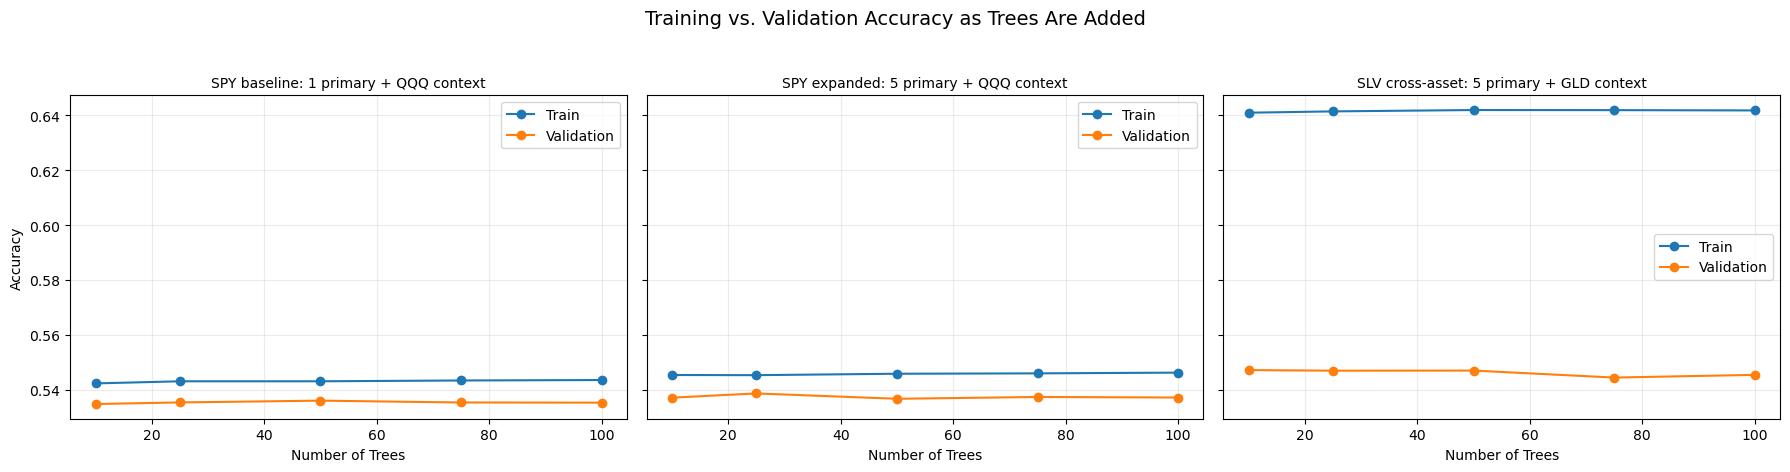

In [5]:
def make_random_forest(n_estimators, warm_start=False):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        warm_start=warm_start,
        **RANDOM_FOREST_SETTINGS,
    )


CURVE_RESULTS = {}
TRAINED_MODELS = {}
RESULTS = []
FEATURE_IMPORTANCE = {}

figure, axes = plt.subplots(
    1,
    len(EXPERIMENTS),
    figsize=(18, 4.5),
    sharey=True,
)
axes = np.atleast_1d(axes)

for axis, experiment in zip(axes, EXPERIMENTS):
    split = SPLITS[experiment["dataset_key"]]
    features = experiment["feature_columns"]

    X_train = split["train"][features]
    y_train = split["train"]["target"]
    X_validation = split["validation"][features]
    y_validation = split["validation"]["target"]

    curve_model = make_random_forest(
        TREE_COUNTS[0],
        warm_start=True,
    )
    train_scores = []
    validation_scores = []

    for tree_count in TREE_COUNTS:
        curve_model.set_params(n_estimators=tree_count)
        curve_model.fit(X_train, y_train)

        train_scores.append(
            accuracy_score(
                y_train,
                curve_model.predict(X_train),
            )
        )
        validation_scores.append(
            accuracy_score(
                y_validation,
                curve_model.predict(X_validation),
            )
        )

    CURVE_RESULTS[experiment["name"]] = pd.DataFrame({
        "Trees": TREE_COUNTS,
        "Train Accuracy": train_scores,
        "Validation Accuracy": validation_scores,
    })

    axis.plot(
        TREE_COUNTS,
        train_scores,
        marker="o",
        label="Train",
    )
    axis.plot(
        TREE_COUNTS,
        validation_scores,
        marker="o",
        label="Validation",
    )
    axis.set_title(experiment["name"], fontsize=10)
    axis.set_xlabel("Number of Trees")
    axis.grid(alpha=0.25)
    axis.legend()

    # Refit on train + validation before the single final test evaluation.
    development = pd.concat(
        [split["train"], split["validation"]],
        axis=0,
    )
    X_development = development[features]
    y_development = development["target"]
    X_test = split["test"][features]
    y_test = split["test"]["target"]

    final_model = make_random_forest(max(TREE_COUNTS))
    final_model.fit(X_development, y_development)
    TRAINED_MODELS[experiment["name"]] = final_model

    test_predictions = final_model.predict(X_test)
    test_probabilities = final_model.predict_proba(X_test)
    test_confidence = test_probabilities.max(axis=1)

    majority_class = int(y_development.mode().iloc[0])
    baseline_predictions = np.full(len(y_test), majority_class)
    selected = test_confidence >= CONFIDENCE_THRESHOLD

    baseline_accuracy = accuracy_score(
        y_test,
        baseline_predictions,
    )
    test_accuracy = accuracy_score(y_test, test_predictions)
    conditional_accuracy = (
        accuracy_score(
            y_test[selected],
            test_predictions[selected],
        )
        if selected.any()
        else np.nan
    )

    RESULTS.append({
        "Model": experiment["name"],
        "Symbol": experiment["symbol"],
        "Cross Symbol": experiment["cross_symbol"] or "None",
        "Primary Features": len(experiment["primary_features"]),
        "Total Features": len(features),
        "Baseline Direction": (
            "UP" if majority_class == 1 else "DOWN"
        ),
        "Baseline Accuracy (%)": round(
            baseline_accuracy * 100,
            2,
        ),
        "Validation Accuracy (%)": round(
            validation_scores[-1] * 100,
            2,
        ),
        "Test Accuracy (%)": round(test_accuracy * 100, 2),
        "Lift vs Baseline (pp)": round(
            (test_accuracy - baseline_accuracy) * 100,
            2,
        ),
        "Confidence Threshold (%)": round(
            CONFIDENCE_THRESHOLD * 100,
            2,
        ),
        "Conditional Accuracy (%)": (
            round(conditional_accuracy * 100, 2)
            if not np.isnan(conditional_accuracy)
            else np.nan
        ),
        "Conditional Coverage (%)": round(
            selected.mean() * 100,
            2,
        ),
        "Conditional Predictions": int(selected.sum()),
    })

    importance = (
        pd.DataFrame({
            "Feature": features,
            "Importance (%)": (
                final_model.feature_importances_ * 100
            ),
        })
        .sort_values("Importance (%)", ascending=False)
        .reset_index(drop=True)
    )
    importance["Importance (%)"] = (
        importance["Importance (%)"].round(2)
    )
    FEATURE_IMPORTANCE[experiment["name"]] = importance

axes[0].set_ylabel("Accuracy")
figure.suptitle(
    "Training vs. Validation Accuracy as Trees Are Added",
    fontsize=14,
    y=1.04,
)
figure.tight_layout()
plt.show()

## 6. Final test results

- **Baseline accuracy:** always predicting the majority class from the
  combined training and validation data
- **Test accuracy:** accuracy across every observation in the untouched test set
- **Conditional accuracy:** accuracy only when the Random Forest's predicted
  probability exceeds the configured confidence threshold
- **Coverage:** percentage of test observations meeting that threshold

Conditional accuracy must always be interpreted together with coverage. A high
conditional accuracy based on very few predictions is less useful than a
slightly lower accuracy that covers a meaningful portion of the test set.

In [6]:
results_table = pd.DataFrame(RESULTS)
display(results_table)

,Model,Symbol,Cross Symbol,Primary Features,Total Features,Baseline Direction,Baseline Accuracy (%),Validation Accuracy (%),Test Accuracy (%),Lift vs Baseline (pp),Confidence Threshold (%),Conditional Accuracy (%),Conditional Coverage (%),Conditional Predictions
0,SPY baseline: 1 primary + QQQ context,SPY,QQQ,1,2,DOWN,50.78,53.54,54.03,3.25,60.0,62.94,3.71,2310
1,SPY expanded: 5 primary + QQQ context,SPY,QQQ,5,6,DOWN,50.78,53.73,53.89,3.11,60.0,68.67,0.88,549
2,SLV cross-asset: 5 primary + GLD context,SLV,GLD,5,6,DOWN,53.31,54.55,57.09,3.78,60.0,68.36,22.51,6303


## 7. Feature importance

Random Forest feature importance reports how much each input contributes to
splitting decisions across the forest. It is useful for comparison, but it
does not prove that a feature causes the next-minute movement.

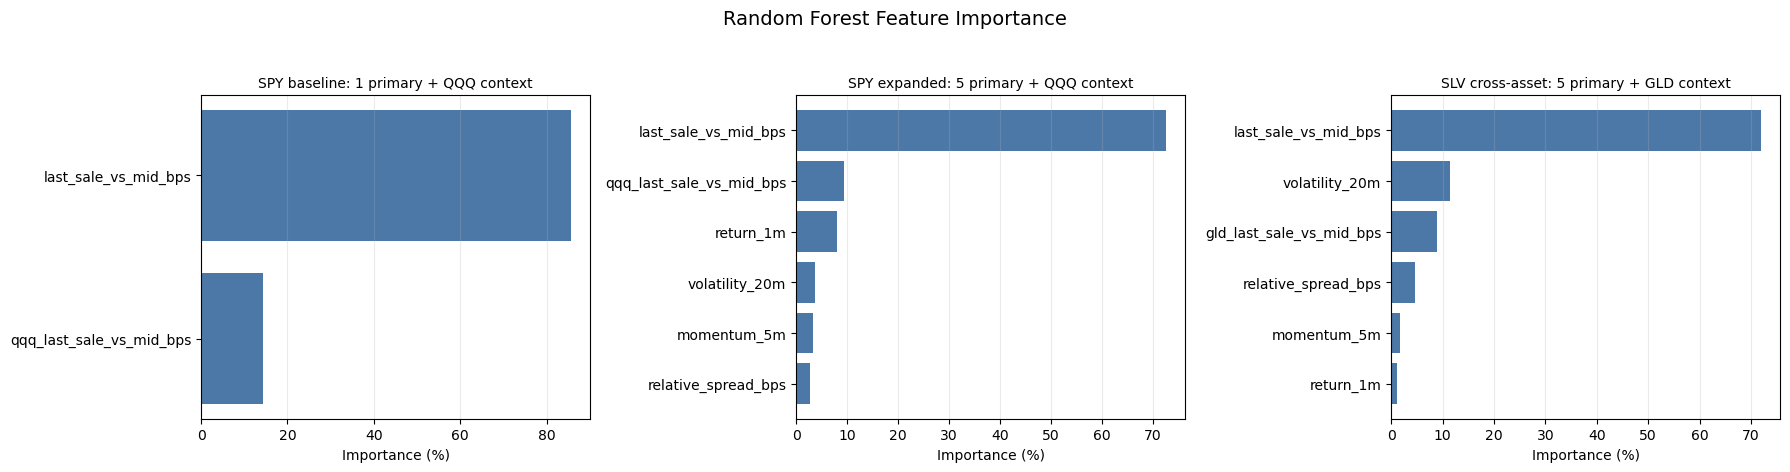


SPY baseline: 1 primary + QQQ context


,Feature,Importance (%)
0,last_sale_vs_mid_bps,85.76
1,qqq_last_sale_vs_mid_bps,14.24



SPY expanded: 5 primary + QQQ context


,Feature,Importance (%)
0,last_sale_vs_mid_bps,72.67
1,qqq_last_sale_vs_mid_bps,9.49
2,return_1m,8.02
3,volatility_20m,3.72
4,momentum_5m,3.39
5,relative_spread_bps,2.71



SLV cross-asset: 5 primary + GLD context


,Feature,Importance (%)
0,last_sale_vs_mid_bps,72.02
1,volatility_20m,11.49
2,gld_last_sale_vs_mid_bps,8.83
3,relative_spread_bps,4.66
4,momentum_5m,1.80
5,return_1m,1.20


In [7]:
figure, axes = plt.subplots(
    1,
    len(EXPERIMENTS),
    figsize=(18, 4.5),
)
axes = np.atleast_1d(axes)

for axis, experiment in zip(axes, EXPERIMENTS):
    importance = FEATURE_IMPORTANCE[experiment["name"]]
    ordered = importance.sort_values(
        "Importance (%)",
        ascending=True,
    )

    axis.barh(
        ordered["Feature"],
        ordered["Importance (%)"],
        color="#4C78A8",
    )
    axis.set_title(experiment["name"], fontsize=10)
    axis.set_xlabel("Importance (%)")
    axis.grid(axis="x", alpha=0.25)

figure.suptitle(
    "Random Forest Feature Importance",
    fontsize=14,
    y=1.04,
)
figure.tight_layout()
plt.show()

for experiment in EXPERIMENTS:
    print(f"\n{experiment['name']}")
    display(FEATURE_IMPORTANCE[experiment["name"]])

## 8. Interpretation and limitations

This experiment is designed to test whether a compact feature set adds
predictive value without introducing unnecessary model complexity. The most
defensible comparison is between the two SPY models because they use identical
rows, timestamps, targets, and split boundaries. The SLV model is a separate
cross-asset case study and should not be treated as a direct SPY comparison.

Several limitations remain:

- The target is next-minute direction, not trading profitability.
- Transaction costs, bid–ask execution, slippage, and market impact are not
  included.
- Zero returns are assigned to DOWN when the neutral-band threshold is zero.
- Conditional accuracy is calculated after selecting predictions by confidence,
  so coverage must be reported beside it.
- Feature importance is descriptive and does not establish causality.
- Results from one historical period may not persist under a different market
  regime.

The practical conclusion should therefore focus on **out-of-sample lift over
the majority baseline, consistency between validation and test accuracy, and
the accuracy–coverage tradeoff** rather than accuracy alone.